<a href="https://colab.research.google.com/github/lassenilssonnn/digital-legal-studies-python/blob/main/notebooks/lesson_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Lesson 6 of Digital Legal Studies!

## Home assignment:

I lied, I haven't finished your assignment yet. I SWEAR, I will upload it in the next two days.


```
def get_him()
  unspeakable_violence...

if lasse_does_not_upload:
  get_him()
```

## Here's what I can tell you.

* Must be uploaded / sent to me before the last class.
* I will give you a few datasets to choose from
* You must answer / figure something out from at least one of them


## Submitting Notebooks

Remember, you need to submit these notebooks, which you do through moodle.
Steps:

1. Access the notebook on Moodle ✅
2. Complete the exercises in the notebook (you have time for this in class)
3. Save the notebook under file, print, save as PDF (which you can choose under destination, if it isn't the default). Save it with your name.
4. Upload it to moodle as a PDF under the correct notebook name.

## POINTS ABOUT PYTHON


To make sure our code works, we want to ensure that we run run cells that are dependent on others first.

```
url = "https://drive.google.com/uc?export=download&id=1LIyC0F1zkwzAT8-m4UtthC5SM8w4WJjO"

data = pd.read_csv(url)


```
If we run the cell below before having run the one above, we are going to get an error.
```
data.head(10)
```

## Is there methods to this madness? - No, but there's attributes.

```
data["year"]
```

Are in pandas the same. It is not a method, but an attribute. It's a little confusing why this is, but just know when you see me doing that-- it's the same.

```
data.year
```



# RECAP

## .iloc  Position-based selection




.iloc selects rows and columns using their numeric position. Think of it as list-slicing. Or list indexing.

```
data.iloc[0:10, [1, 4]] # index based selection, starting with rows then columns
```

.iloc is not inclusive, it does not include the last index, so 0:10 gives us the first 10 posts but not post[10].


## .loc → Label-based selection

.loc selects rows and columns using their names or labels. This is more like selecting values from a dictionary.




```
data.loc[0:5, ["Country", "year"]] #→ rows 0–5, only the columns Country and year
```

This selects the data from 0:5 (with .loc) we include the 5 (we call it inclusive).

Remember than we can search for places where rows meet conditions, by adding them to the left side of the comma (where we have columns, so where 0:5 was in our above example.


```
data.loc[(data.Country == "Turkey") & (data.Judgement_type == "violation"), ["Country", "year]]
```



```
&  # is the same as 'and' and what we use in pandas
```


```
| # is the same as 'or' and what we use in pandas.
```



## IMPORTANT TO RUN CELL BELOW.

In [ ]:
import pandas as pd

url = "https://drive.google.com/uc?export=download&id=1LIyC0F1zkwzAT8-m4UtthC5SM8w4WJjO"

data = pd.read_csv(url)

In [ ]:
data.iloc[0:10, [1, 4]] # index based selection, starting with rows then columns

,Document_Title,Conclusion
0,CASE OF EREN v. TURKEY,Violation of Art. 6-1;Not necessary to examine...
1,CASE OF EREN v. TURKEY,Violation of Art. 6-1;Not necessary to examine...
2,CASE OF FIX v. GREECE,Violation of Art. 6-1;Violation of Art. 13
3,CASE OF FIX v. GREECE,Violation of Art. 6-1;Violation of Art. 13
4,CASE OF FIX v. GREECE,Violation of Art. 6-1;Violation of Art. 13
5,CASE OF MAKOVOZ v. RUSSIA,Violation of Article 3 - Prohibition of tortur...
6,CASE OF HALMAGIU AND BELLU v. ROMANIA,Violation of Article 1 of Protocol No. 1 - Pro...
7,CASE OF BAŞAR v. TURKEY,No violation of Article 3 - Prohibition of tor...
8,CASE OF BELTRAM AND BELTRAM CEROVŠEK v. SLOVENIA,Violation of Article 6 - Right to a fair trial...
9,CASE OF BELTRAM AND BELTRAM CEROVŠEK v. SLOVENIA,Violation of Article 6 - Right to a fair trial...


## CLEANING THE DATA

Before we start doing stuff, we always want to make sure the data is clean. Think of yourself as a Data Heisenberg and you don't want the DEA (me) to come after you for using dirty data. (I should stick to teaching, this isn't an open mic...) We remember that we have a method that allows us to drop NA, (not available). It takes an argument called subset, which tells it what column the values should ba NA in.

It's important to clean this data, because if we want to run statistics or say something meaningful, we can't be making do with poor data.

In this case, I know that there were NA values in importance, and I also saw a string "key_cases" appear multiple times.

In [ ]:
## We clean the data here.

data.dropna(subset=["Importance"])

data = data.loc[(data.Importance!="key_cases")]



data["Importance"] = pd.to_numeric(data["Importance"]) # We are doing stuff with this later


## Grouping Data with `groupby()`

So far we have summarized **single columns**.

For example:

```python
data["Country"].value_counts()
```

This tells us how many cases each country has.

But often we want to ask more complicated questions such as:

* What is the latest case year for each country?
* How many cases does each country have per year?

To answer questions like this, we use `groupby()`.


## Basic idea

`groupby()` splits the dataset into groups that share the same value. To use it, we group data, and then run a method on that data.

You can think of it as each group we generate as being a slice of our DataFrame containing only data with values that match.

So it looks through each row, and kind of says okay, whatever we're grouped by, I will choose the rows that share that column and then do some operation on it.

Example:

In [ ]:
data.groupby("year").year.count()

,year
year,
1968,9
1969,7
1970,2
1971,12
1975,5
1976,22
1978,11
1979,17
1980,13



This looks weird, but what it does is:

1. groupby("year")

“Split the dataset into groups based on the values in the year column.”

2. .year

This is column selection after grouping.

“From each group, take the year column.”

3. .count()

“Count how many non-missing values there are in that column for each group.”

## Another example

In [ ]:
data.groupby("Country").year.min()

,year
Country,
Albania,2004
Andorra,2004
Armenia,2007
Austria,1968
Azerbaijan,2006
Belgium,1968
Bosnia and Herzegovina,2007
Bulgaria,1997
Croatia,2001


Logic here is split the dataset into groups based on the values in the Country column. From each group take the year column, and apply the min() function to each group's year column.

In [ ]:
data.head(2)

,Application_Number,Document_Title,Document_Type,Originating_Body,Conclusion,Violation,Article,Paragraph,Subparagraph,Language,Document_Collection,Country,date,year,Importance,Judgement_type,Definition,label,all_labels
0,NaN,CASE OF EREN v. TURKEY,HEJUD,Court (Third Section),Violation of Art. 6-1;Not necessary to examine...,6-1-0,6,1,0,english,judgments,Turkey,2003-10-23,2003,3.0,violation,Right to a fair trial,6: Right to a fair trial,6: Right to a fair trial
1,NaN,CASE OF EREN v. TURKEY,HEJUD,Court (Third Section),Violation of Art. 6-1;Not necessary to examine...,6-0-0,6,0,0,english,judgments,Turkey,2003-10-23,2003,3.0,violation,Right to a fair trial,6: Right to a fair trial,6: Right to a fair trial


# Challenge time!


I want you to group the countries (by their country) and tell me the .mean() of their Importance columns.

So, group them by country, access the column you want, and run a method on it-- the .mean method, to be exact.




Once you've done that and it prints a list, add .sort_values() to it.

so in the end it should should be (some code here).mean().sort_values()

In [ ]:
## Make the code here!

## RENAMING COLUMNS

When we work with data, we often 'inherit' the column names. Sometimes, these are some fine inheritances indeed, but otherwise, we're not so lucky.

Column names are obviously good indicators of what is hiding in their rows, so we want clear, simple names that indicate this; we also want them to be uniform, so we make fewer logic errors.

Let's look at our column names.

In [ ]:
data.iloc[0:0]

,Application_Number,Document_Title,Document_Type,Originating_Body,Conclusion,Violation,Article,Paragraph,Subparagraph,Language,Document_Collection,Country,date,year,Importance,Judgement_type,Definition,label,all_labels


If we do that, we see that date, year, label, and all_labels are lowercase, but the others are upper case.

Sometimes column names in a dataset are unclear, inconsistent, or hard to read. Pandas lets us rename them using .rename().

We use a method called .rename, and we pass a dictionary with the key being that which we wish to change and the value the change, we wish to see.

Example:

```

data = data.rename(columns={'date': "Date", "year":"Year", "label":"Label", "all_labels":"All_labels"})

```
Like many pandas operations, .rename() does not change the dataframe unless we assign it. So that's why we have data =


If you're wondering about

```
columns=
```

that is a key-word argument. So far, we've only been placing arguments into functions using their position. Let's say a function takes (x, y)

```
def my_function(x,y):
  # some code
```

If I were to use it, I could use it like function(put in x, put in y), using the position outlined. I could also do



```
my_function(y=my_y_value, x=my_x_value)
```
So even though x should go first, by using key word arguments I can displace this. That's sometimes nice for clarity when reading code.


## Challenge time!

Rename the columns that are currently lower_case to start with uppercase.

In [ ]:
# Do that here!

In [ ]:
data.head(2) #let's check the data!

,Application_Number,Document_Title,Document_Type,Originating_Body,Conclusion,Violation,Article,Paragraph,Subparagraph,Language,Document_Collection,Country,date,year,Importance,Judgement_type,Definition,label,all_labels
0,NaN,CASE OF EREN v. TURKEY,HEJUD,Court (Third Section),Violation of Art. 6-1;Not necessary to examine...,6-1-0,6,1,0,english,judgments,Turkey,2003-10-23,2003,3.0,violation,Right to a fair trial,6: Right to a fair trial,6: Right to a fair trial
1,NaN,CASE OF EREN v. TURKEY,HEJUD,Court (Third Section),Violation of Art. 6-1;Not necessary to examine...,6-0-0,6,0,0,english,judgments,Turkey,2003-10-23,2003,3.0,violation,Right to a fair trial,6: Right to a fair trial,6: Right to a fair trial


## LAMBDA FUNCTIONS!


These are my favorite functions, they're sexy, practical, and awesome!


Sometimes we want to apply a function to every value in a column.

We can do this with `.map()`.

Example:

```
data.Document_Title.map(lambda x: x.lower())
```

This does the following:

1. Takes every value in `Document_Title` column
2. Applies a function to it
3. Returns the transformed values

---

## What is `lambda`?

A lambda function is a small anonymous function.

Example:

```
lambda x: x * 10
```

the lambda key word is simply telling python that, the next 'variable' in this case x, is simply a stand in for whatever is in that row.

So it means take X (whatever value that will get),


So when we write:

```
data.Document_Title.map(lambda x: x.lower())
```

we are saying:

> "Take every row in document title (which will be the document title) and convert it to lowercase."

In [ ]:
# Here's an example of the tiny function, when we use the map, we don't need to assign lambda to a variable
tiny_function = lambda x: x * 3

tiny_function(3)

9

We can also make more complicated lambda functions.

Example:

You can see how the syntax goes, it's a little different, since it's one line of code. Think of it as inversing the logic. Instead of if... then low. Here's it's low... if.

We are making a new column with our data["importance_level"] =

In [ ]:
data["importance_level"] = data["Importance"].map(lambda x:
    "Low" if x == 1 else "Medium" if x == 2 else "High")

In [ ]:
data.head(5)

,Application_Number,Document_Title,Document_Type,Originating_Body,Conclusion,Violation,Article,Paragraph,Subparagraph,Language,Document_Collection,Country,date,year,Importance,Judgement_type,Definition,label,all_labels,importance_level
0,NaN,CASE OF EREN v. TURKEY,HEJUD,Court (Third Section),Violation of Art. 6-1;Not necessary to examine...,6-1-0,6,1,0,english,judgments,Turkey,2003-10-23,2003,3.0,violation,Right to a fair trial,6: Right to a fair trial,6: Right to a fair trial,High
1,NaN,CASE OF EREN v. TURKEY,HEJUD,Court (Third Section),Violation of Art. 6-1;Not necessary to examine...,6-0-0,6,0,0,english,judgments,Turkey,2003-10-23,2003,3.0,violation,Right to a fair trial,6: Right to a fair trial,6: Right to a fair trial,High
2,1001/09,CASE OF FIX v. GREECE,HEJUD,Court (First Section),Violation of Art. 6-1;Violation of Art. 13,6-1-0,6,1,0,english,judgments,Greece,2011-07-12,2011,3.0,violation,Right to a fair trial,6: Right to a fair trial,"6: Right to a fair trial,13: Right to an effec...",High
3,1001/09,CASE OF FIX v. GREECE,HEJUD,Court (First Section),Violation of Art. 6-1;Violation of Art. 13,13-0-0,13,0,0,english,judgments,Greece,2011-07-12,2011,3.0,violation,Right to an effective remedy,13: Right to an effective remedy,"6: Right to a fair trial,13: Right to an effec...",High
4,1001/09,CASE OF FIX v. GREECE,HEJUD,Court (First Section),Violation of Art. 6-1;Violation of Art. 13,6-0-0,6,0,0,english,judgments,Greece,2011-07-12,2011,3.0,violation,Right to a fair trial,6: Right to a fair trial,"6: Right to a fair trial,13: Right to an effec...",High


## Challenge time!

I want you to capitalize every row in the english column. So each row says, at that column "English", or "Spanish" (if there are any such rows).

Remember, we saw a method that helped us do that, google it if you can't remember it, or think of other ways to solve it.

I want you to use a lambda function and the map method to apply that function to every row in that column.

Hints: there's no need to do conditional lambdas or anything.

In [ ]:
## Do it in this cell!

# It's plotting time, baby.

Matplotlib is one of the main plotting libraries in Python. We use it to turn data into visual representations such as line charts, bar charts, and other graphs.

At the most basic level, plotting means three things:

* we choose some data

* we choose how to display it

* we show the result

A plot helps us see patterns, trends, and differences more easily than if we only look at raw numbers.


## Our first plot

In the next cell, we make a very simple line plot.

The first list gives the values on the x-axis.
The second list gives the values on the y-axis.

So if we write:

x-values: [1, 2, 3]

y-values: [10, 20, 15]

Matplotlib draws points at those positions and connects them with a line.

This is the simplest way to make a plot: give Python some values, tell it what kind of plot you want, and display it.

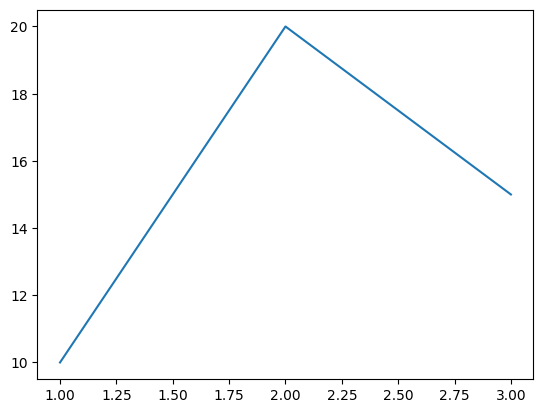

In [ ]:
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

## What is happening behind the scenes?

Even though the code for a simple plot is short, Matplotlib is still organizing the plot in a structured way.

Behind the scenes, it works with two important ideas:

* a figure: the full image or canvas

* an axis: the area inside that image where the data is drawn

When we use a very simple command like plt.plot(), Matplotlib creates these parts for us automatically.

That is convenient at first. But later, when we want more control over titles, labels, multiple plots, or layout, it helps to understand that this structure is there.

What is happening behind the scenes?

Even though the code for a simple plot is short, Matplotlib is organizing the plot in a structured way.

It works with two key components:

a figure: the full image or canvas

an axis: the area inside that image where the data is drawn

When we use a simple command like:

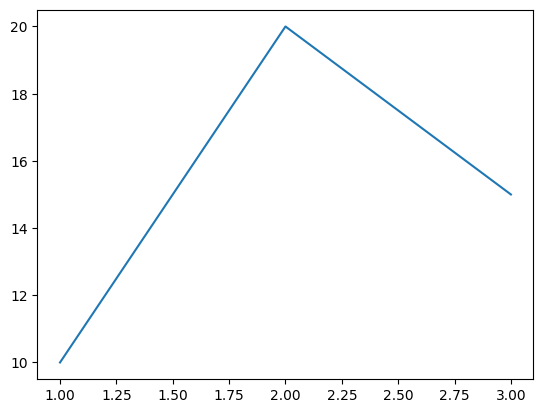

In [ ]:
plt.plot([1, 2, 3], [10, 20, 15])

Matplotlib creates both of these automatically for us.

## Figure and axis

When working more directly with Matplotlib, we separate these two parts explicitly:

* The figure is the whole image

* The axis is the part of the image where the data is actually plotted

So, the figure is the page, and the axis is the chart on that page.

### Why this matters

A single figure can contain multiple axes. In other words, one image can contain several plots.

This structure becomes important when we want more control over:

* titles and labels

* layout

* multiple plots in the same figure


>The figure holds everything, but the axis is where the data is actually drawn.

## Creating a plot with more control

So far, we have used simple plotting commands.

Now we will make the structure explicit by creating a figure and an axis.

We will start with simple (dummy) data so it is clear what is happening.

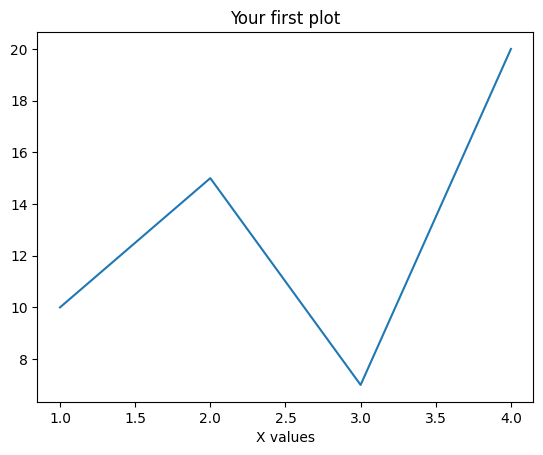

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = [10, 15, 7, 20]

fig, ax = plt.subplots()

ax.plot(x, y)


ax.set_title("Your first plot")
ax.set_xlabel("X values")
plt.show()

### What is happening here?

We are now being more explicit about how Matplotlib builds a plot.

```python
fig, ax = plt.subplots()
```

This creates:

* **fig** → the full figure (the whole image)
* **ax** → the axis (the area where we draw the data)


### Step by step

```python
ax.plot(x, y)
```

We draw the data on the axis.

```python
ax.set_xlabel("X values")
```
We label the x-axis.

```python
ax.set_title("Your first plot")
```
We give it a title.

```python
plt.show()
```

We display the final result.


### Key idea

Even though we created both `fig` and `ax`, all the actual plotting happens on **ax**.

That is why every command starts with `ax.`


### Exercise!

Modify the plot in the above cell to add a label for the **y-axis**. Look at how we did the x axis, and try to imagine how we do the Y axis...

## Plotting real data

So far, we have used simple dummy data to understand how Matplotlib works.

Now we will use our actual dataset.

We will start with a **bar chart**, which is useful when we want to compare categories.

A good first example is the number of cases by country.

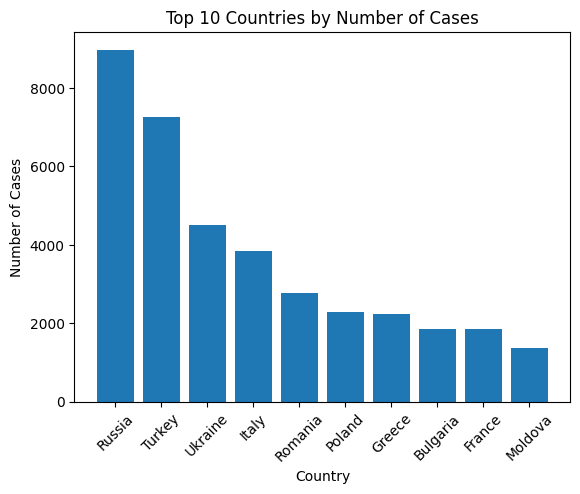

In [ ]:
top_countries = data["Country"].value_counts().head(10)

fig, ax = plt.subplots()

ax.bar(top_countries.index, top_countries.values)

ax.set_title("Top 10 Countries by Number of Cases")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Cases")

plt.xticks(rotation=45)
plt.show()

### What are we doing here?

First, we count how many times each country appears in the dataset:

```
data["Country"].value_counts().head(10)
```

This gives us the 10 countries with the most cases.

Then we use:

```
ax.bar(...)
```

To create a bar chart.

Bar charts are useful when we want to compare categories.

* the x-axis shows the categories (countries)

* the y-axis shows the counts (number of cases)

We also rotate the country names with:

```
plt.xticks(rotation=45)
```
so that the labels are easier to read.

## Comparing judgement types across countries

So far, we have looked at how many cases each country has.

Now we want to go one step further:

> For each country, how many cases are *violations* and how many are *non-violations*?

We will:

* focus on the **10 countries with the most cases**
* split their cases into two groups:

  * violation
  * non-violation
* show both in the **same bar chart**

The goal is to compare not just *how many* cases there are, but also *what kind* of cases they are.


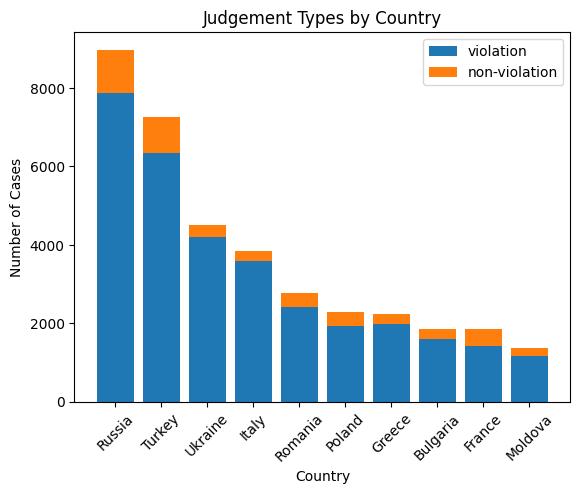

In [ ]:
# 1. get top 10 countries (with counts)
top_10 = data["Country"].value_counts().head(10)

# 2. filter data to only those countries
data_top_10 = data[data["Country"].isin(top_10.index)]

# 3. count judgement types per country
violations = data_top_10[data_top_10["Judgement_type"] == "violation"]["Country"].value_counts()
non_violations = data_top_10[data_top_10["Judgement_type"] == "non-violation"]["Country"].value_counts()

# 4. plot
fig, ax = plt.subplots()

ax.bar(top_10.index, violations, label="violation")
ax.bar(top_10.index, non_violations, bottom=violations, label="non-violation")

ax.set_title("Judgement Types by Country")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Cases")

plt.xticks(rotation=45)
plt.legend()

plt.show()

## What did we just do?

Let’s break it down using only things we already know.

### 1. Find the top 10 countries

We used:

```
data["Country"].value_counts().head(10)
```

We have already seen this:

* `data["Country"]` → take one column
* `.value_counts()` → count how many times each value appears
* `.head(10)` → keep the first 10 (the biggest ones)

This gives us **both names and counts**.

To get just the country names, we use:

```
top_10.index
```

This means:

> “Give me only the country names”


### 2. Keep only those countries

We used:

```
data["Country"].isin(top_10.index)
```

We have seen this pattern before:

* `.isin(...)` checks if a value is in a list
* it returns **True / False for each row**

So this line means:

> “Keep only rows where the country is in our top 10”

### 3. Count violations (step by step)

Now the important line:

```
violations = data_top_10[
    data_top_10["Judgement_type"] == "violation"
]["Country"].value_counts()
```

This is just a **pipeline of actions**:

1. start with the data
2. Filter it
3. count it

Let’s break it down!:

**Step 1 — check each row**

```
data_top_10["Judgement_type"] == "violation"
```

→ True/False for each row

**Step 2 — keep only True rows**

```
data_top_10[ ... ]
```

→ now we only have *violation cases*

**Step 3 — focus on countries + count**

```
["Country"].value_counts()
```

→ count how many times each country appears

So the whole thing means:

> “Keep only violations, then count how many each country has”

We do the exact same thing for `"non-violation"`.


### 4. Plot the bars

We already know:

```
ax.bar(x, y)
```

So first:

```
ax.bar(top_10.index, violations)
```

→ draw the **first layer** (violations)

Then:

```
ax.bar(top_10.index, non_violations, bottom=violations)
```

The new part is:

```
bottom=violations
```

This means:

> “Start these bars on top of the first ones”

So the bars are stacked.


## Heatmaps

A heatmap is another way of showing values using color instead of bar height.

Darker or more intense colors usually represent larger values, while lighter colors represent smaller values.

In this example, we are not counting cases. Instead, we are looking at how variables relate to each other.

We calculate something called a correlation.

Correlation tells us:

- how strongly two variables are related
- whether they increase together or move in opposite directions

Each square in the heatmap shows the correlation between two variables.

So instead of comparing categories, we are now comparing relationships between variables using color.

### Preparing data for correlation

Before we can calculate correlations, we need to work only with numeric variables. Correlation only works with numbers — not text like "violation" or "non-violation".

So we select numeric columns

year
Importance

These are already numeric, so they are ready to use.

2. Turn text into numbers

Right now, "Judgement_type" is text: "violation" and "non-violation"

But correlation cannot use text. So we convert it into a number:

* violation → 1

* non-violation → 0

This is called a binary variable (only two possible values).

In [ ]:
numeric_data_for_corr = data[["year", "Importance"]].copy()

# create a binary variable
numeric_data_for_corr["Is_violation"] = (data["Judgement_type"] == "violation").astype(int)

# as type returns 1 for True and 0 for not True

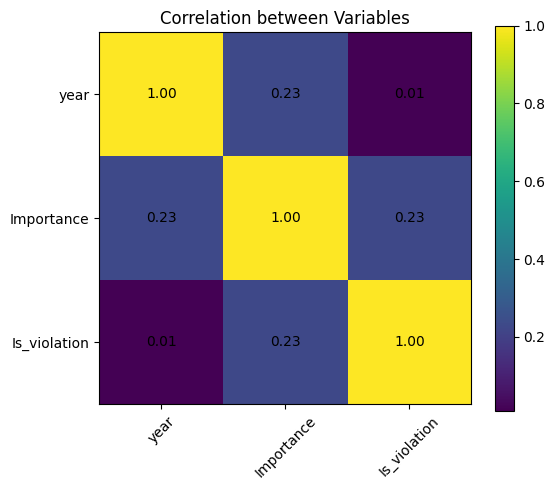

In [ ]:
corr_matrix = data_numeric.corr()

fig, ax = plt.subplots(figsize=(6, 5)) #try changing the figsize to like (10, 9) or other combinations

image = ax.imshow(corr_matrix, cmap="viridis")

#try different colors for cmap by changing the string "viridis"
#- Try cividis, YlGnBu, plasma

ax.set_title("Correlation between Variables")

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45)

ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

# ADD NUMBERS
for row in range(len(corr_matrix)):
    for col in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[row, col]
        ax.text(col, row, f"{value:.2f}", ha="center", va="center")

plt.colorbar(image)
plt.show()

# Question: What does this tell us?

## What does it mean that Importance and Is_violation have a positive correlation?

## How about is_violation and year? And how about importance?




## Building the heatmap step by step

Let’s walk through what is happening here. Some of these lines do quite a lot behind the scenes.

### 1. Create the correlation matrix


In [ ]:
corr_matrix = numeric_data_for_corr.corr()

print(corr_matrix)

                  year  Importance  Is_violation
year          1.000000    0.228950      0.009713
Importance    0.228950    1.000000      0.226175
Is_violation  0.009713    0.226175      1.000000


### 2. Turn the matrix into an image

```python
image = ax.imshow(corr_matrix, cmap="viridis")
```

`imshow()` takes the table of numbers and turns it into a grid of colors.

Each square = one value from the correlation matrix.

The variable `image` just stores that colored grid so we can use it later (for example, to add the colorbar).


### 3. Add labels

```python
ax.set_xticks(...)
ax.set_xticklabels(...)

ax.set_yticks(...)
ax.set_yticklabels(...)
```

These lines just make the plot readable.

They add the variable names along the axes so we know what each row and column represents.

### 4. Add the numbers

We loop through the matrix and write the values inside each square.

So instead of guessing from color, we can see the exact numbers.


### 5. Color scale

```python
plt.colorbar(image)
```

This adds a legend showing what the colors mean.


### The idea

* `.corr()` → creates the relationships
* `imshow()` → turns them into colors
* labels + numbers → make it readable
